# ARIM情報活用講座：　ケモインフォマテックス 編　
# 第5回：　スクリーニング

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**：ARIMデータポータル会員の研究者・技術者を想定しています。Pythonの基礎文法は理解しているものとしますが、RDKit・scikit-learnに触れるのは初めてでも読み進められるように構成しています。統計学・機械学習の予備知識は前提としません。

**前提知識**：Python基礎文法、3_Solubility.ipynb（PLSモデルの構築・保存）および4_Structure_Generation.ipynb（仮想ライブラリの生成）の内容（本編はその続編です）。実行には`models/9.3_rdkit_pls.joblib`と`results/mol_quad.smi`が必要です。

**動作環境**：Google Colab、または以下のバージョンで動作確認を行いました。

| ライブラリ | バージョン |
| --- | --- |
| Python | 3.10 |
| rdkit | 2026.03.4 |
| scikit-learn | 1.7.2 |
| pandas / numpy | 2.3.3 / 1.26.4 |

**版とライセンス**：底本は船津 公人、柴山 翔二郎『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』（近代科学社、2020）第9章第3節。データセットの出典は本編内で明記します。本ノートブックはARIMデータポータルセミナー・ワークショップ教材として配布します。


## 底本
船津 公人、柴山 翔二郎 **『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』**、近代科学社、2020  
第９章第３節　プロジェクトの例/ 解析例２：水溶解度データと構造生成

## 本編の目標
4_Structure_Generation.ipynbでは3,000の仮想化合物のバーチャルライブラリを作成しました。本編では、これらの化合物から候補材料を見つけます。以下の４つを念頭に進めます。

* 教師データから適用範囲（AD）を定めます。ここではT2指標、Q値という距離指標を用います。
* 第４回で構造生成した仮想ライブラリを予測器にかけ、適用範囲（AD）内に収まる化合物をスクリーニングします。

## データセット
delaney-processed.csvは1128化合物の水溶解度についてのデータセットです。このデータセットは、Delaneyの論文『ESOL: Estimating Aqueous Solubility Directly from Molecular Structure』[1] で発表されたものに基づいています。

[1] John S. Delaney, "ESOL:  Estimating Aqueous Solubility Directly from Molecular Structure", J. Chem. Inf. Comput. Sci. 44, 1000–1005 (2004) (DOI: 10.1021/ci034243x)  

Delaney-processed.csvは、分子の化学式、SMILES表記、および水溶解度（log S、mol/L単位の対数値）の実測値・予測値が含まれており、これらの特性は薬物探索や環境影響評価などの目的で使用されています。

《注意》水溶解度（log S）とオクタノール水分配係数（log P）は異なる物性値です。このデータセットにはlog P列は含まれていません。

1. Compound ID	：化合物ID
1. ESOL predicted log solubility in mols per litre　：log水溶解度の予測値（ESOLモデルによる推定値）	
1. Minimum Degree：　最小次数	
1. Molecular Weight：分子量	
1. Number of H-Bond Donors	：　水素結合に関与するDonor数
1. Number of Rings	：分子内の全環数（芳香環・脂肪族環を問わない）	
1. Number of Rotatable Bonds　：　回転可能結合数	
1. Polar Surface Area　：　極性表面積	
1. measured log solubility in mols per litre：log水溶解度の実測値	
1. smiles：SMILES表記

# Google Colabにおける環境設定
google colab環境でなければ実行不要

In [ ]:
!!pip install rdkit
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Chemoinformatics.git
%cd Advanced_Tutorial_3_Chemoinformatics

## 1.分子構造データの読み込み （P.130）
### ライブラリのインポート

In [1]:
#データ構造化ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

#機械学習ライブラリ
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cross_decomposition import PLSRegression
from sklearn import metrics

#記述子ライブラリ
from rdkit import Chem
from rdkit.Chem.AllChem import GetHashedMorganFingerprint

from warnings import filterwarnings
filterwarnings('ignore')# 警告を無視

### サンプルファイルの読み込み
1_Descriptor.ipynbと同じく「data/dataset」フォルダーにあるdelaney-processed.csvをpandasの`read_csv()`で読み込みます。RDKitの`MolFromSmiles`関数を[smiles]列に適用してmol構造への変換オブジェクトを[mol]列とする流れも同様です。

In [2]:
df=pd.read_csv('./data/dataset/delaney-processed.csv')
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x7b3ab13a19a0>
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x7b3ab13a1a10>
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x7b3ab13a1a80>
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x7b3ab13a1af0>
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x7b3ab13a1b60>
...,...,...,...,...,...,...,...,...,...,...,...
1123,halothane,-2.608,1,197.381,0,0,0,0.00,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x7b3aaeaa4970>
1124,Oxamyl,-0.908,1,219.266,1,0,1,71.00,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x7b3aaeaa49e0>
1125,Thiometon,-3.323,1,246.359,0,0,7,18.46,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x7b3aaeaa4a50>
1126,2-Methylbutane,-2.245,1,72.151,0,0,1,0.00,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x7b3aaeaa4ac0>


### データセットの分割（Data set splitting）
分割は`test_size=0.2`として訓練データ：0.8、テストデータ：0.2とします。

In [3]:
df_train, df_test = train_test_split(df, 
                                     test_size=.20, 
                                     random_state=42)

目的変数を'measured log solubility in mols per litre'にセットします。

In [4]:
ytrain = df_train['measured log solubility in mols per litre']

In [5]:
from cheminfo.descriptors import RDKitDescriptor
rdcalc = RDKitDescriptor()

X = rdcalc.fit_transform(df_train['mol'])
Xtrain = np.array(X.tolist())

#X2 = rdcalc.transform(df_test['mol'])
#Xtest = np.array(X2.tolist())

### 機械学習モデル

In [6]:
params = {'n_components': np.arange(1, 16)}
optim = GridSearchCV(PLSRegression(), params)

In [7]:
optim.fit(Xtrain, ytrain)

,estimator,PLSRegression()
,param_grid,"{'n_components': array([ 1, 2..., 13, 14, 15])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,14


In [8]:
#ycalc = optim.predict(Xtrain)
#ypred = optim.predict(Xtest)

## 3.適用範囲（AD）の設定
4_Structure_Generation.ipynbで作成した3,000の仮想化合物にたいして、上記のRDKit記述子をベースとしたPLSモデルによる予測を行います。また、予測結果が信頼できるかを確認するため、底本ではT2指標、Q値から適用範囲を定めています。 


【補足】  
T2指標とQ値は、生産における品質管理に関連する統計的な手法です。主に多変量データを分析し、プロセスの安定性や品質の変化を監視するために使用されます。

1. **T2指標 (T2 Statistic)**:
T2指標は、多変量プロセス監視のための統計的な指標で、プロセス内の変動や異常を検出するのに役立ちます。基本的には、多変量データの平均値と分散の組み合わせを用いて計算されます。T2指標はホテリングのT²統計量（Hotelling's T² statistic）に基づいています。

T2指標は、以下の手順で計算されます：
1. データセットの平均ベクトル（多変量データの平均値）を計算します。
2. データセットの共分散行列（多変量データの分散共分散行列）を計算します。
3. プロセスから得られたデータの平均ベクトルを計算し、それを基準平均ベクトルと比較します。
4. プロセスから得られたデータの共分散行列を計算し、それを基準共分散行列と比較します。

T2は距離指標であり、その測長には**マハラノビス距離**を用いています。これよりT2値（マハラノビス距離）を計算し、特定の閾値と比較することで、プロセスの異常や変化を監視することができます。

2. **Q値 (Q Statistic)**:
Q値も多変量プロセス監視のための指標で、プロセス内の変動や異常を検出する際に使用されます。T2指標と同様に、Q値も異常を検出するための基準となる閾値と比較されます。

Q値は、データの観測値が平均値からどれだけ離れているかを示す指標で、基本的にはT2指標の計算における差異ベクトルを用いて計算されます。Q値は、各観測値の差異ベクトルの長さを示し、この長さが閾値を超える場合に異常と判定されることがあります。

なお、T2指標、Q値は関数は次のようにdef関数として使います。PLSに対してT2指標、Q値を適用した内容については下記の技術ブログも参照してください。  
https://nirpyresearch.com/outliers-detection-pls-regression-nir-spectroscopy-python/

### 数理的な定義

PLSモデルにおいて、あるサンプル`x`のスコアベクトルを`t`（`x`をPLSの回転行列に射影したもの）とすると、**T2指標**は各成分のスコアを訓練データでの標準偏差で正規化（ホワイトニング）した上での二乗和として計算されます：

```
T2 = Σ_j (t_j / σ_j)^2
```

ここで`σ_j`はj番目のPLS成分（スコア）の訓練データにおける標準偏差です。マハラノビス距離の2乗に相当する量になります。

**Q値**は、PLSの主成分だけでは説明しきれない残差（訓練データの主成分空間から元の記述子空間へ再構成した際のズレ）を表します。ローディング行列を`P`とすると、再構成値は

```
x̂ = t・P^T
```

で計算され、Q値はこの再構成誤差の二乗和です：

```
Q = ||x - x̂||^2
```

《注意：スケールの一致について》PLSモデルは内部で記述子を標準化（平均0・分散1）してから主成分を計算しています（`PLSRegression`のデフォルト引数`scale=True`）。したがって上式の`x`と`x̂`は、いずれも標準化後の座標で比較する必要があります。標準化前の生の値（例えばRDKit記述子の`Ipc`は1兆を超える値を取ることがあります）と、標準化された座標系での再構成値をそのまま差し引いてしまうと、Q値が単位不整合のまま桁違いに巨大な値になってしまいます。実際、底本付属の`cheminfo.metrics.q_value`関数のソースコードには、標準化前の座標に戻すための`* model.best_estimator_.x_std_ + model.best_estimator_.x_mean_`という処理がコメントアウトされたまま残されており、この不整合を修正しようとした痕跡がうかがえます。次のセルの`q_value`関数は、`x`と`x̂`を同じ標準化座標系で比較するように実装しています。


In [9]:
def t2_score(data, model):
    "T2値の計算モジュール"
    assert type(data)==pd.DataFrame or type(data)==np.ndarray, "input must be pandas.DataFrame or np.array"
    
    explained_std_ = np.sqrt(model.best_estimator_.x_scores_.var(axis=0))
    scores_whiten = model.transform(data) / explained_std_
    
    return (scores_whiten ** 2.). sum(axis=1)

def q_value(data, model):
    """Q値の計算モジュール

    【修正】底本付属のcheminfo.metrics.q_value関数は、標準化前の生データ(data)と、
    PLS内部の標準化座標系での再構成値(x_reproduced_)を、単位を揃えないまま
    差し引いていた（ソースコードには標準化前の座標に戻す処理がコメントアウトされた
    まま残っていた）。この不整合により、Ipcのような桁の大きい記述子がQ値の計算を
    支配し、Q値が本来無意味な巨大な数値（10^11オーダー）になってしまっていた。
    ここでは、生データ側も同じ標準化座標系に変換してから差を取るように修正している。
    """
    assert type(data)==pd.DataFrame or type(data)==np.ndarray, "input must be pandas.DataFrame or np.array"
    
    best = model.best_estimator_
    data_scaled = (np.asarray(data) - best._x_mean) / best._x_std
    x_reproduced_ = model.transform(data) @ best.x_loadings_.T
    
    return ((data_scaled - x_reproduced_)**2.).sum(axis=1)


### 適用範囲（AD）の設定
ADの設定範囲はdelaneyの溶解度データの教師データよりT2指標およびQ値を計算し、その範囲を定めます。Xtrainデータ（教師データ）よりT2指標とQ値を計算し、その累積確率が95%となる点（95%タイル値）を適用範囲の上限として設定します。

《注意》T2指標・Q値はいずれも0以上の値しか取らない非対称な分布（カイ二乗分布に近い形）になるため、正規分布を前提とした「2σ」という表現は適切ではありません。片側95%点は分布の形状に依存するため、ここでは実データから直接分位点（`np.quantile(..., 0.95)`）を計算して求めています（参考：標準正規分布であれば片側95%点は約1.64σ、両側2σの区間に含まれる確率は約95.4%であり、両者は一般には一致しません）。


### T2指標およびQ値の計算

In [10]:
t2_values = t2_score(Xtrain, optim)
q_values = q_value(Xtrain, optim)

In [11]:
#t2_values

### ADの上限値設定
ここではT2指標およびQ値の95%タイル値を適用範囲の上限として設定しています。


In [12]:
t2_95q = np.quantile(t2_values, 0.95)
qval_95q = np.quantile(q_values, 0.95)

print('t^2 - 95% quantile', t2_95q, '\nq value - 95% quantile', qval_95q)

t^2 - 95% quantile 35.1572313530782 
q value - 95% quantile 300.26290945378383


### ADの可視化
設定されたADの範囲をプロットします。横軸をT2指標、縦軸をQ値とし、それぞれの95% quantileを破線で表示します。

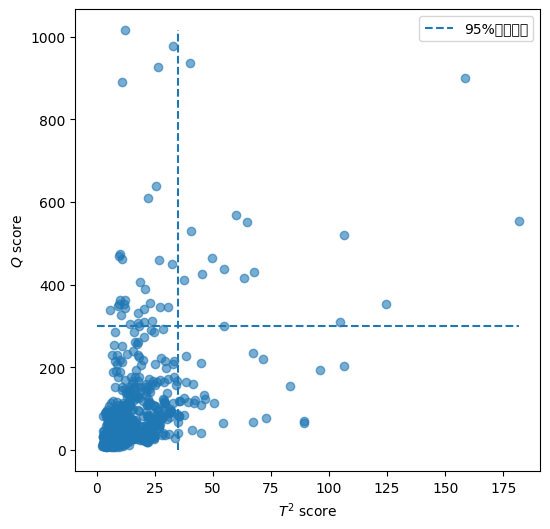

In [13]:
# 図1：訓練データのT2指標・Q値の分布と適用範囲（AD）の95%タイル値
plt.figure(figsize=(6,6))
plt.plot(t2_values, q_values, 'o', alpha=0.6)

plt.xlabel('$T^2$ score')
plt.ylabel('$Q$ score')
plt.vlines(t2_95q, ymin=0, ymax=q_values.max(), linestyles='--', label='95%タイル値')
plt.hlines(qval_95q, xmin=0, xmax=t2_values.max(), linestyles='--')
plt.legend()

plt.show()


ADの範囲がわかるように軸設定を変更します。

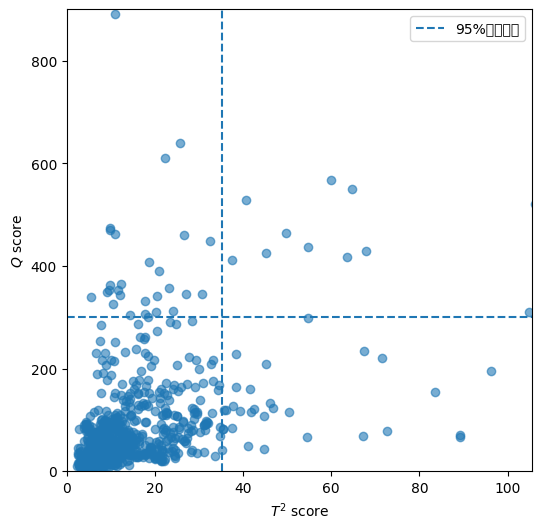

In [14]:
# 図2：AD境界付近を拡大した図（T2・Q値それぞれ95%タイル値の3倍までの範囲を表示）
plt.figure(figsize=(6,6))
plt.plot(t2_values, q_values, 'o', alpha=0.6)

plt.xlabel('$T^2$ score')
plt.ylabel('$Q$ score')

plt.xlim(0, t2_95q * 3)
plt.ylim(0, qval_95q * 3)
plt.vlines(t2_95q, ymin=0, ymax=qval_95q * 3, linestyles='--', label='95%タイル値')
plt.hlines(qval_95q, xmin=0, xmax=t2_95q * 3, linestyles='--')
plt.legend()

plt.show()


## 4.スクリーニング
4_Structure_Generation.ipynbで生成した3,000の仮想化合物について並列処理によるPLSの予測器にかけて演算します。演算結果をSMILES構造（smi）、溶解度の予測値（ypred）, 当該予測値のt2指標（t2）および q値（q）の4つを.outファイルとして出力します。

### 並列処理によるスクリーニング

《注意》multiprocessingの挙動はOSに依存します（4_Structure_Generation.ipynbの《注意》も参照）。Linux（Google Colab、および多くのローカルLinux環境を含む）では既定のfork方式が使われるため、下のセルはJupyter Notebook上でも問題なく動作します（本編はLinux環境で実際に動作確認済みです）。Windows・macOSでは挙動が異なる場合があるため、うまく動作しない場合はセルの再実行やカーネルの再起動を試してください。

In [4]:
from joblib import load as jl_load
from multiprocessing import Pool, cpu_count

from rdkit.Chem import MolFromSmiles

from cheminfo.descriptors import RDKitDescriptor
# 【修正】cheminfo.metricsのt2_score/q_valueにはスケール不整合のバグがあるため、
# ここでは再インポートしない。3節冒頭で修正済みのt2_score/q_value関数を使う。

次の`processor()`関数はmultiprocessで並列処理がかけられるように、仮想ライブラリのデータを読み込み、またPLSモデルから溶解度の予測値、およびT2指標とQ値を返すコードになります。

《注意》以前はこのセルで`cheminfo.metrics`から`t2_score`・`q_value`を独立したモジュールとして読み込み直していましたが、`cheminfo.metrics.q_value`には前節で発見したスケール不整合のバグが含まれているため、ここでは再インポートしません。Linux（fork方式）の`multiprocessing`では、`Pool()`生成時点での親プロセスのグローバル名前空間がそのまま子プロセスに引き継がれるため、`processor()`関数は3節冒頭で修正済みの`t2_score`・`q_value`関数をそのまま正しく参照できます。


In [5]:
def processor(argv):
    """予測値とSMILESを文字列で返す関数。multiprocessing.Pool.imap用。"""
    smiles, model = argv
    smi = smiles.strip()

    mol = MolFromSmiles(smi)
    mol.UpdatePropertyCache(strict=True)
    rdcalc = RDKitDescriptor()
    xnew = np.array(rdcalc.transform([mol]))
    
    ypred = model.predict(xnew)
    t2 = t2_score(xnew, model)
    q = q_value(xnew, model)
    return '%s %.8f %.8f %.8f'%(smi, ypred, t2, q)


`count_lines()`関数は、入力するmol_quad.smiファイルの行数をカウントする関数です。

In [6]:
def count_lines(filename):
    """ファイルの行数を数える関数"""
    with open(filename, 'r')as f:
        c=0
        for _ in f:
            c+=1
    return c

次のmain()関数はpyでは基本処理の部分となります。最適化されたモデルファイルおよび仮想ライブラリの.smiを読み込み、15行目から並列処理を行います。

In [7]:
def main():
    """メイン関数。入力を受け取り、並列処理を実行。"""
    # assert len(argv)>2, "SYNTAX: python src/10.3-screening.py MODEL_FILE.joblib SMILES.smi"
    modelfile = "./models/9.3_rdkit_pls.joblib"
    smilesfile = "./results/mol_quad.smi"

    model = jl_load(modelfile)
    n_counts = count_lines(smilesfile)

    cs = 1000

    model_sampler = (model for _ in range(n_counts))
    outfile = open(smilesfile.replace('.smi', '.out'), 'w')

    with open(smilesfile, 'r') as f:
        with Pool(cpu_count()) as pool:
            "並列処理"
            for ret in pool.imap(processor, zip(f, model_sampler), chunksize=cs):
                outfile.write(ret+'\n')
    outfile.close()# 開いたファイルオブジェクトは必ず閉じる。

In [8]:
main()

### ADによるスクリーニング
得られた.outを下記のようにopen関数で読み出して、AD以下に入る化合物をカウントします。

4_Structure_Generation.ipynbで`frag_library`の順序を決定的にする修正を行っているため（同ノートブックの【修正】箇所を参照）、`mol_quad.smi`の内容・カウントの数は実行のたびに変わらず再現します。

In [9]:
count = 0 
with open('./results/mol_quad.out', 'r') as f:
    for line in f:
        line = line.strip()
        info = line.split()
        
        if float(info[2])<=t2_95q and float(info[3])<=qval_95q:
            count += 1
    else:
        print('予測結果の信頼できる化合物の数', count)

予測結果の信頼できる化合物の数 209


## ①まとめ

- 訓練データ（Xtrain）から計算したT2指標・Q値の95%分位点を適用範囲（AD）の上限として設定しました（図1・図2）。
- 4_Structure_Generation.ipynbで生成した3,000の仮想化合物にPLSモデルを適用し、AD内に収まる化合物を絞り込みました。
- ADを設定することで3,000のうち、上記の「予測結果の信頼できる化合物の数」に絞り込まれました。この中から予測値が高い化合物が候補材料として見ることができます。
- その化合物の中からどの材料を実際に実験するかは、最終的には人の判断に委ねられます。溶解度の高い上位のランキングのものにするのも一案です。
- 実験計画法としてのベイズ最適化（底本P101）を使って選択する方法もあります。今回のセミナーではベイズ最適化についてはカリキュラムには含めていませんが、機械学習モデルとあわせてベイズ最適化を使うことで効率的にターゲットを絞り込み、所望の化合物（物性）を得るまでの時間を軽減させることができます。

### シリーズを振り返って

このノートブックは、1_Descriptor.ipynbから続く一連のシリーズの最終回にあたります。ここまでの流れを振り返ると、次のような一つながりのMI（マテリアルズインフォマティクス）ワークフローになっていたことがわかります。

1. **1_Descriptor.ipynb**：Delaneyデータセット1128化合物から、分子記述子・フィンガープリントという「化合物を数値化する手段」を学びました。
2. **2_Dimensionality_Reduction.ipynb**：得られた高次元の記述子空間を、タニモト係数による類似性やPCA・t-SNE・UMAPで可視化し、化学空間の構造を眺める方法を学びました。
3. **2-2_Fragment_Count.ipynb**：部分構造（フラグメント）の出現頻度という、別の切り口の特徴量を学びました。
4. **3_Solubility.ipynb**：これらの特徴量を説明変数として、水溶解度を予測するPLSモデルを構築し、`models/9.3_rdkit_pls.joblib`として保存しました。
5. **4_Structure_Generation.ipynb**：BRICSによるフラグメントの組み換えで、実在しない3,000個の仮想化合物からなるバーチャルライブラリ（`results/mol_quad.smi`）を生成しました。
6. **5_Screening.ipynb（本編）**：3・4回で作った「予測モデル」と「仮想ライブラリ」を組み合わせ、適用範囲（AD）という統計的な歯止めをかけながら、3,000化合物の中から**209化合物**まで絞り込みました。

つまりこのシリーズは、「実測データを数値化する」→「その数値空間を理解する」→「数値から物性を予測するモデルを作る」→「モデルを使って未知の候補を生み出す」→「その候補のうちモデルが自信を持って予測できる範囲のものだけを選び出す」という、材料探索のミニマムなパイプラインを一通り体験できる構成になっています。実務では、ここで絞り込んだ候補の中からさらに実験・計算による検証を行い、その結果を教師データに加えて再度モデルを更新する（データを増やしながらモデルを育てていく）というサイクルを回していくことになります。6_Catalyst.ipynbでは、同じ「記述子化→モデル構築→評価」という考え方を、高分子・水溶解度とは全く異なる触媒探索という題材に適用しており、本シリーズで学んだ考え方が特定のデータセットに限らず汎用的に使えることを確認できます。

## ②本ノートブックで扱っていないこと（今後の課題）

- AD内に絞り込んだ化合物を、溶解度の予測値でランキングして上位を表示する処理は行っていません。
- T2指標・Q値以外の適用範囲設定手法（k近傍距離に基づく手法など）との比較は行っていません。
- ベイズ最適化による効率的な探索（底本P101）は本セミナーの範囲外です。

## ③演習問題

1. `.out`ファイルを読み込み、AD内に収まった化合物を予測溶解度（ypred）の降順に並べ替えて、上位10化合物のSMILESを表示してみましょう。
2. AD上限を95%タイル値ではなく99%タイル値に変更すると、AD内に収まる化合物の数はどう変化するか確認してみましょう。
3. 図1・図2のプロットに、AD内外で色分け（例：AD内は青、AD外は赤）を追加してみましょう。
